In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt


import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein

import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968
cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

In [2]:
path = '../target_selection/photom_redshift_distribution/'
mag_max_eval_range=[[23, 24.5], 
                    [24.2, 26], 
                    [24.2, 26], [24.2, 26]]
config_survey_dark = {'survey_type': 'Dark',
                 'N_fibres': 30000,
                'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [ path+f'COSMOS_QSO_WST_QSO_no_H.npz', 
                                        path+f'COSMOS_LBG_udropout_highz.npz', 
                                        path+f'COSMOS_LBG_gdropout.npz',
                                        path+f'COSMOS_LBG_rdropout.npz'
                 ],
                 'tracers' : ['QSO', 
                              'LBGu',
                     'LBGg','LBGr'
                 ],
                    'color' : ['k', 'm', 'g', 'r']}
config_dark_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey_dark,mag_max_eval_range=mag_max_eval_range, max_mag=None)   

In [3]:
config_dark_update.keys()

dict_keys(['survey_type', 'N_fibres', 'S_FoV', 'S_survey', 'exposure_time', 'observation_fraction', 'tracer_N_zm_file', 'tracers', 'color', 'QSO_target_density', 'QSO_spec_density', 'QSO_spec_redshift_density', 'QSO_target_redshift_density', 'QSO_target_pointings', 'QSO_fibre_time', 'QSO_calendar_time', 'QSO_mag_centers', 'QSO_redshift_centers', 'LBGu_target_density', 'LBGu_spec_density', 'LBGu_spec_redshift_density', 'LBGu_target_redshift_density', 'LBGu_target_pointings', 'LBGu_fibre_time', 'LBGu_calendar_time', 'LBGu_mag_centers', 'LBGu_redshift_centers', 'LBGg_target_density', 'LBGg_spec_density', 'LBGg_spec_redshift_density', 'LBGg_target_redshift_density', 'LBGg_target_pointings', 'LBGg_fibre_time', 'LBGg_calendar_time', 'LBGg_mag_centers', 'LBGg_redshift_centers', 'LBGr_target_density', 'LBGr_spec_density', 'LBGr_spec_redshift_density', 'LBGr_target_redshift_density', 'LBGr_target_pointings', 'LBGr_fibre_time', 'LBGr_calendar_time', 'LBGr_mag_centers', 'LBGr_redshift_centers'])

In [4]:
res = _survey_design_science_metrics.Survey_design_science_metrics(config_dark_update, cosmo, 
                                                                   redshift_eval_range =[[0, 4],
                                                                                         [2, 4.5], [2.5, 5], [4, 6]], 
                                                                   mag_max_eval_range=mag_max_eval_range,
                                                                   multi_mag_bin_approach = [False, True, True, True])

Computing forecasts: Survey  Dark  --- tracer:  QSO
Computing forecasts: Survey  Dark  --- tracer:  LBGu
Now, forecasts are done considering 2 samples
Computing forecasts: Survey  Dark  --- tracer:  LBGg
Now, forecasts are done considering 2 samples
Computing forecasts: Survey  Dark  --- tracer:  LBGr
Now, forecasts are done considering 2 samples


(22.5, 26.0)

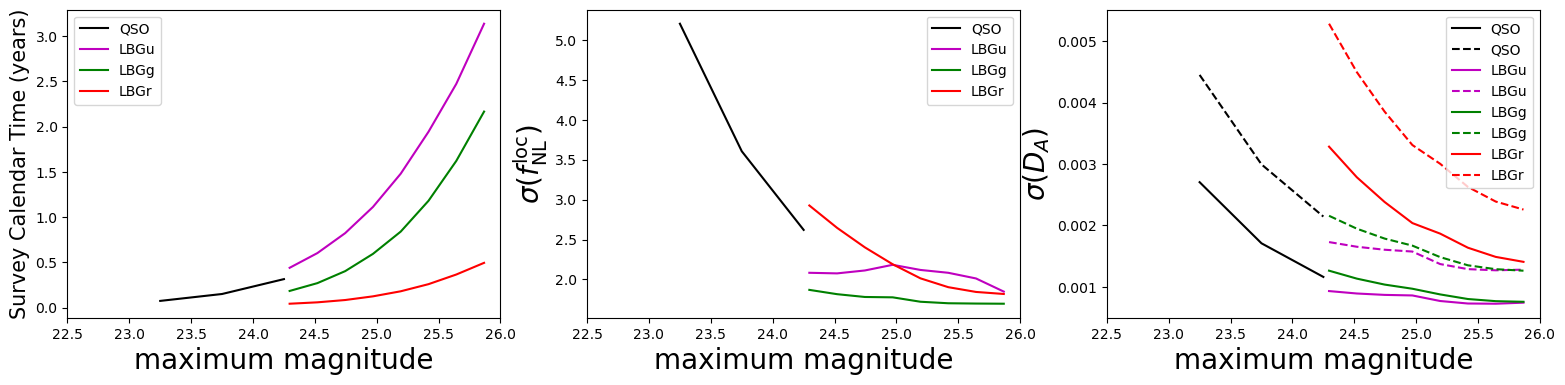

In [5]:
plt.figure(figsize=(19, 4))
plt.subplot(131)
for i,tracer in enumerate(config_dark_update['tracers']):
    
    plt.plot(res[tracer+'_mag_max_eval'], config_dark_update[tracer + '_' + 'calendar_time'] , color = config_dark_update['color'][i], label = tracer)
plt.legend()
plt.ylabel(r'Survey Calendar Time (years)', fontsize=15)
plt.xlabel('maximum magnitude', fontsize=20)
plt.xlim(22.5, 26)

plt.subplot(132)
for i,tracer in enumerate(config_dark_update['tracers']):

    plt.plot(res[tracer+'_mag_max_eval'], res[tracer+'_sigma_fnl_eff'] , color = config_dark_update['color'][i], label = tracer)

plt.legend()
plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
plt.xlabel('maximum magnitude', fontsize=20)
plt.xlim(22.5, 26)

plt.subplot(133)
for i,tracer in enumerate(config_dark_update['tracers']):
    
    plt.plot(res[tracer+'_mag_max_eval'], res[tracer+'_sigma_Da_eff'] , color = config_dark_update['color'][i], label = tracer)
    plt.plot(res[tracer+'_mag_max_eval'], res[tracer+'_sigma_H_eff'] , '--', color = config_dark_update['color'][i], label = tracer)

plt.legend()
plt.ylabel(r'$\sigma(D_A)$', fontsize=20)
plt.xlabel('maximum magnitude', fontsize=20)
plt.xlim(22.5, 26)

Text(0.5, 0, 'Survey Calendar Time (year)')

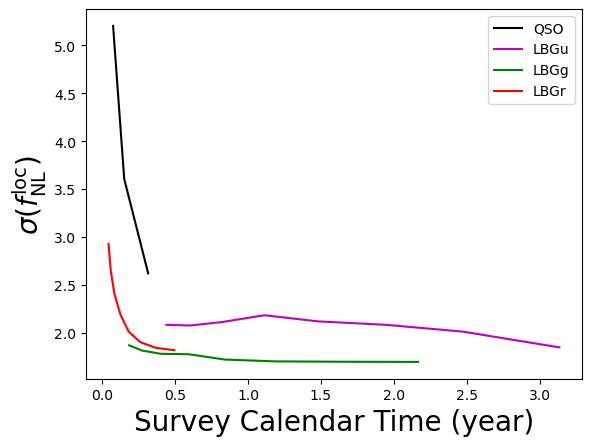

In [6]:
for i,tracer in enumerate(config_dark_update['tracers']):

    plt.plot(config_dark_update[tracer + '_' + 'calendar_time'] ,res[tracer+'_sigma_fnl_eff'] ,color = config_dark_update['color'][i], label = tracer)

plt.legend()
plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
plt.xlabel('Survey Calendar Time (year)', fontsize=20)
#plt.xscale('log')


In [7]:
def best_idx(FoM):
    FoM[I['total_survey_time'] > 5] = 0
    best_idx = np.unravel_index(
        np.argmax(FoM),
        FoM.shape
    )
    return best_idx

In [8]:
I = _survey_design_science_metrics.build_total_survey_information_metrics(config_dark_update, res)

NameError: name 'Information_fnl' is not defined

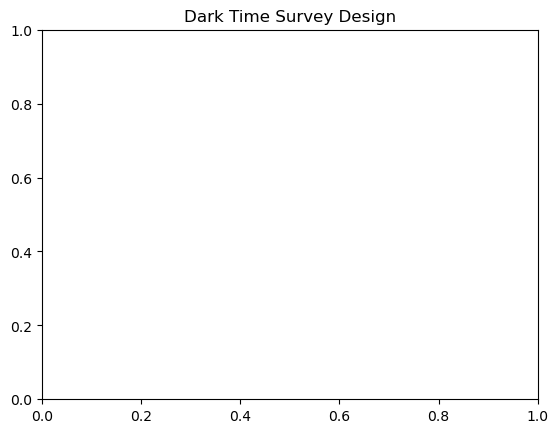

In [9]:
plt.title('Dark Time Survey Design')
plt.scatter(Information_fnl.flatten()**(-0.5), 1e4*Information_Da.flatten()**(-0.5), c = I['total_survey_time'].flatten(),
            vmin=0.5,
            vmax =7, cmap='gist_rainbow', marker='o', s=40, label = 'Dark Time survey designs')
plt.ylabel(r'$\sigma(D_A)\times 10^4$', fontsize=15)
plt.xlabel(r'total $\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
cbar = plt.colorbar()

sigma_Da_target = 0.0006
sigma_fnl_target = 1.1

FoM_all = (sigma_fnl_target **2 * Information_fnl + sigma_Da_target **2 * Information_Da)
FoM_fnl = sigma_fnl_target **2 * Information_fnl
FoM_Da = sigma_Da_target **2 * Information_Da

plt.scatter(1/Information_fnl[best_idx(FoM_all)]**.5, 1e4/Information_Da[best_idx(FoM_all)]**.5, marker='p', color='g', s=300, edgecolors='k',label = 'Combined')

plt.scatter(1/Information_fnl[best_idx(FoM_Da)]**.5, 1e4/Information_Da[best_idx(FoM_Da)]**.5, marker='*', color='b', s=300, edgecolors='k', label = r'Optimizing $D_A$ from BAO scales')
plt.scatter(1/Information_fnl[best_idx(FoM_fnl)]**.5,1e4/Information_Da[best_idx(FoM_fnl)]**.5, marker='s', color='m', s=200, edgecolors='k',label = r'Optimizing $f_{\rm NL}^{\rm loc}$ from large-scale PS')
cbar.set_label(r'Survey Calendar Time (years)', fontsize=20)
plt.legend(loc='upper left')

In [ ]:
plt.title('Dark Time: QSO+LBGugr')
x = 2*np.random.random(len(I['total_survey_time'].flatten())) -1
plt.scatter(I['total_survey_time'].flatten() + 0.2*x*np.linspace(-1, 1, len(I['total_survey_time'].flatten())), 1/Information_fnl**.5,
            c=I['total_survey_efficiency'].flatten(), s=10, label = 'Combined', cmap='jet', vmin=0.4, vmax=0.6, alpha=0.5)
plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
plt.xlabel(r'Survey total time (years)', fontsize=10)
cbar = plt.colorbar()
cbar.set_label(r'$n_{\rm spec}/n_{\rm target}$', fontsize=20)

In [ ]:
best_mags = {}

for tracer, idx in zip(config_dark_update['tracers'], best_idx(FoM_all)):
    best_mags[tracer] = res[tracer + '_mag_max_eval'][idx]
best_mags['total time'] = total_time[best_idx(FoM_all)]

print(best_mags)